# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [32]:
# importar librerías
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import levene, ttest_ind

In [33]:
# cargar archivo
df = pd.read_csv('landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [4]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Hallazgos**
 - No se observan valores nulos.
 - La columna `date` tiene un tipo de datos Object por lo que se realizará la corrección del tipo de datos a date.

In [6]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df["user_id"].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()


count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
usuarios_convertidos = df[df["converted"] == 1]

resumen_convertidos = usuarios_convertidos["gasto"].describe()

print("Resumen estádistico de gasto - usuarios con conversión: ")
print(resumen_convertidos)


Resumen estádistico de gasto - usuarios con conversión: 
count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:

# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print()# Salto de Línea

print(" ---- Landing ----")#completa el código)
print(df["landing"].value_counts())
print()# Salto de Línea

print(" ---- Region ----")#completa el código)
print(df["region"].value_counts())
print()# Salto de Línea

print(" ---- Traffic_source ----")#completa el código)
print(df["traffic_source"].value_counts())
print()# Salto de Línea


print(" ---- User_type ----")#completa el código)
print(df["user_type"].value_counts())
print()# Salto de Línea

print(" ---- Dispositivo ----")#completa el código)
print(df["dispositivo"].value_counts())






Conteo de categorías:

 ---- Landing ----
B    20018
A    19982
Name: landing, dtype: int64

 ---- Region ----
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

 ---- Traffic_source ----
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

 ---- User_type ----
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

 ---- Dispositivo ----
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64


In [10]:
# 1. Verificación de duplicados explícitos.

duplicados = df.duplicated().sum()

# 2. Validación de la columna "converted" Solo debe de haber 0 y 1
valores_converted = df["converted"].unique()

# 3. Consistencia Lógica: ¿Hay usuarios con gasto > 0 pero converted == 0 ?
inconsistencia_gasto = df[(df["gasto"] > 0) & (df["converted"] == 0)].shape[0]

#4. Verificación de tipos de datos y nulos (Reforzado)
print(f"Duplicados totales en el DataFrame: {duplicados}")
print(f"Valores únicos en 'Converted': {valores_converted} (Esperado: [0, 1])")
print(f"Casos inconsistentes (Gasto sin conversión): {inconsistencia_gasto} (Esperado: 0)")

Duplicados totales en el DataFrame: 0
Valores únicos en 'Converted': [1 0] (Esperado: [0, 1])
Casos inconsistentes (Gasto sin conversión): 0 (Esperado: 0)



✍️ **Hallazgos**:
- Todas las columnas tienen valores esperados.

**Evidencia de Validación de Datos:**
   * **Integridad:** Se confirmó la ausencia de registros duplicados y valores nulos en el dataset (0 nulos detectados).
   * **Consistencia Lógica:** Se validó que no existen registros con montos de gasto (total_spent) sin una marca de conversión exitosa (converted), asegurando la coherencia entre el comportamiento del usuario y el registro financiero.
   * **Dominio de Variables:** La variable objetivo converted cumple estrictamente con el formato binario $[0, 1]$, y las variables categóricas (landing, traffic_source, user_type) no presentan categorías "fantasma" o errores de captura.
   * **Temporalidad:** El rango de fechas es continuo, lo que garantiza que el experimento no sufrió interrupciones técnicas que pudieran sesgar los resultados.
   
**Conclusión:** El dataset se considera apto y robusto para el análisis estadístico, habiendo superado los controles de calidad de integridad y consistencia lógica.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [26]:

# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"] #completa el código
gasto_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"]#completa el código


stat_levene, p_levene = levene(gasto_A, gasto_B)

print(f"Prueba de Levene - Estadístico: {stat_levene:.4f}, Valor P: {p_levene:.4}")

# 3. Decisión basada en Levene

if p_levene < 0.05:

  print("Resultado: Varianzas heterogéneas (diferentes). Usaremos T-test de Welch (equal_var=False).")
  equal_variances = False
else:
  print("Resultado: Varianzas homogéneas (iguales). Usaremos T-test estándar (equal_var=True).")
  equal_variances = True



Prueba de Levene - Estadístico: 29.1765, Valor P: 6.875e-08
Resultado: Varianzas heterogéneas (diferentes). Usaremos T-test de Welch (equal_var=False).


In [18]:
t_stat, t_pvalue = ttest_ind(gasto_A, gasto_B, equal_var = equal_variances)

print(f"\nPrueba T - Estadístico: {t_stat:.4}, Valor P: {t_pvalue}")

if t_pvalue < 0.05:
  print("Conclusión: Existe una diferencia significativa en el gasto promedio.")
else:
  print("Conclusión: No existe evidencia suficiente para afirmar una diferencia en el gasto")


Prueba T - Estadístico: -9.481, Valor P: 3.627602231521493e-21
Conclusión: Existe una diferencia significativa en el gasto promedio.


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los usuarios convertidos en la página A es igual al gasto promedio en la página B ($\mu_A = \mu_B$).
- **Hipótesis alternativa (H₁):** El gasto promedio de los usuarios convertidos en la página A es diferente al gasto promedio en la página B ($\mu_A \neq \mu_B$).

In [21]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B)


# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


In [22]:
print(f"Promedio A: {gasto_A.mean():.2f}")
print(f"Promedio B: {gasto_B.mean():.2f}")

Promedio A: 61.09
Promedio B: 68.75


### 📝 Conclusión e interpretación

**Decisión:**  
El valor p es extremadamente inferior al nivel de significancia de $0.05$. Se rechaza $H_0$.

**Interpretación de negocio:**  
Existe evidencia estadística contundente de que el gasto promedio entre las páginas es diferente. La Página B no solo atrae más conversiones, sino que el valor económico que genera por cada cliente es significativamente superior al de la Página A.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia significativa entre la tasa de conversión de la página A ($p_A$) y la página B ($p_B$).
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa entre la tasa de conversión de la página A ($p_A$) y la página B ($p_B$).

In [27]:
# Número de usuarios convertidos por página

conversiones = df.groupby("landing")["converted"].sum()
observaciones = df.groupby("landing")["converted"].count()

exitos = [conversiones["A"], conversiones["B"]]
muestras = [observaciones["A"], observaciones["B"]]


# Total de usuarios por página

print(f"Usuarios convertidos por página:\n{conversiones}")
print(f"\nTotal de usuarios por página:\n{observaciones}")



tasa_A = (conversiones["A"] / observaciones["A"]) * 100
tasa_B = (conversiones["B"] / observaciones["B"]) * 100

print(f"\nTasa de conversión A: {tasa_A:.2f}%")
print(f"\nTasa de conversión B: {tasa_B:.2f}%")




Usuarios convertidos por página:
landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
landing
A    19982
B    20018
Name: converted, dtype: int64

Tasa de conversión A: 12.57%

Tasa de conversión B: 15.96%


In [28]:
# Aplicar prueba

stat, p_value = proportions_ztest(
    count=exitos,
    nobs=muestras)


# Visualizar resultados
print(f"Estadístico Z: {stat:.4f}")
print(f"Valor p: {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Hay una diferencia significativa entre las tasas de conversión de la página A y B")
else:
    print("\nConclusión: No hay evidencia suficiente para rechazar la hipótesis nula.")
    print("Las tasas de conversión son estadísticamente similares")

Estadístico Z: -9.6774
Valor p: 0.0000

Conclusión: Rechazamos la Hipótesis Nula.
Hay una diferencia significativa entre las tasas de conversión de la página A y B


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la Hipótesis nula, ya que hay una diferencia significativa entre las tasas de conversión de la página A y B.


**Interpretación de negocio:**  
Existe una diferencia estádisticamente significativa entre las tasas de conversión de ambas páginas.
Mientras que la página A tiene ujna tasa de conversión de 12.57%, la Página B logra una tasa superior del 15.96%

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La fuente de tráfico (traffic_source) y la conversión (converted) son independientes. (No existe relación entre el canal de origen y la probabilidad de compra).
- **Hipótesis alternativa (H₁):** La fuente de tráfico (traffic_source) y la conversión (converted) son dependientes. (El canal de origen influye significativamente en la probabilidad de conversión).

In [ ]:
# Aplicar prueba
# Se crea la tabla de frecuencias

tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])

# Se ejecuta prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)

print(" ***Análisis de Fuente de Tráfico vs Conversión*** ")
print(f"Estádistico Chi-cuadrada: {chi2_stat:.4f}")
print(f"Valor P: {p_value:.4f}")







 ***Análisis de Fuente de Tráfico vs Conversión*** 
Estádistico Chi-cuadrada: 8.6621
Valor P: 0.0341



Tasas de conversión por fuente de tráfico:

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


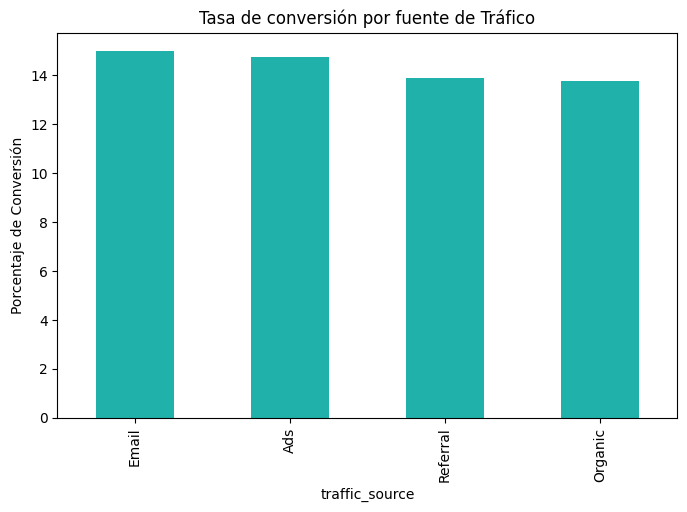

In [ ]:
#Tabla para visualizar tasa de conversión por fuente

tasa_por_fuente = pd.crosstab(df["traffic_source"], df["converted"], normalize="index") * 100

print("\nTasas de conversión por fuente de tráfico:")
print()
print(tasa_por_fuente)

#Visualización.
tasa_por_fuente[1].sort_values(ascending=False).plot(kind="bar", color="lightseagreen", figsize=(8, 5))
plt.title("Tasa de conversión por fuente de Tráfico")
plt.ylabel("Porcentaje de Conversión")
plt.show()


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la Hipótesis nula. El Valo P es menor que nuestro nivel alpha 0.05.

**Interpretación de negocio:**  

Existe una asociación estadística entre la fuente de tráfico y la conversión. Analizando la tabla de porcentajes, podemos ver el rendimiento real de cada canal:

•	**Email** (14.99%): Es el canal más eficiente. Casi el 15% de las personas que llegan por correo terminan comprando.

•	**Ads** (14.73%): Muy cerca del email; es un canal sólido que está trayendo usuarios con alta intención de compra.

•	**Referral** (13.88%) y **Organic** (13.78%): Aunque son buenos, tienen una tasa de conversión ligeramente menor (casi 1.2 puntos porcentuales por debajo del Email).



## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuario (user_type) y la conversión (converted) son independientes. (Ser un usuario nuevo o recurrente no afecta la probabilidad de compra).
- **Hipótesis alternativa (H₁):** El tipo de usuario (user_type) y la conversión (converted) son dependientes. (Existe una diferencia en el comportamiento de conversión basada en la experiencia previa del usuario).

In [29]:
# Aplicar prueba

tabla_usuario = pd.crosstab(df["user_type"], df["converted"])

# Se ejecuta prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)

print(" ***Análisis de Tipo de Usuario vs Conversión*** ")
print(f"Estádistico Chi-cuadrado: {chi2_stat:.4f}")
print(f"Valor P: {p_value:.4f}")

 ***Análisis de Tipo de Usuario vs Conversión*** 
Estádistico Chi-cuadrado: 0.5135
Valor P: 0.4736


In [30]:
#Tabla de Porcentajes

tasa_por_usuario = pd.crosstab(df["user_type"], df["converted"], normalize="index") * 100
print("\nTasas de conversión por tipo de usuario:")
print()
print(tasa_por_usuario)



Tasas de conversión por tipo de usuario:

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula ya que el valor p (0.4736) es considerablemente mayor que 0.05.

**Interpretación de negocio:**  
No existe una asociación estadísticamente significativa entre el tipo de usuario (Nuevo vs. Recurrente) y la conversión.

•	**Análisis de las tasas:** Los usuarios Nuevos convierten al 14.35%, mientras que los Recurrentes lo hacen al 14.09%. Con una diferencia de apenas 0.26 puntos, indica que la página es igual de efectiva para convencer a alguien que entra por primera vez como a alguien que ya conocía el sitio.


## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

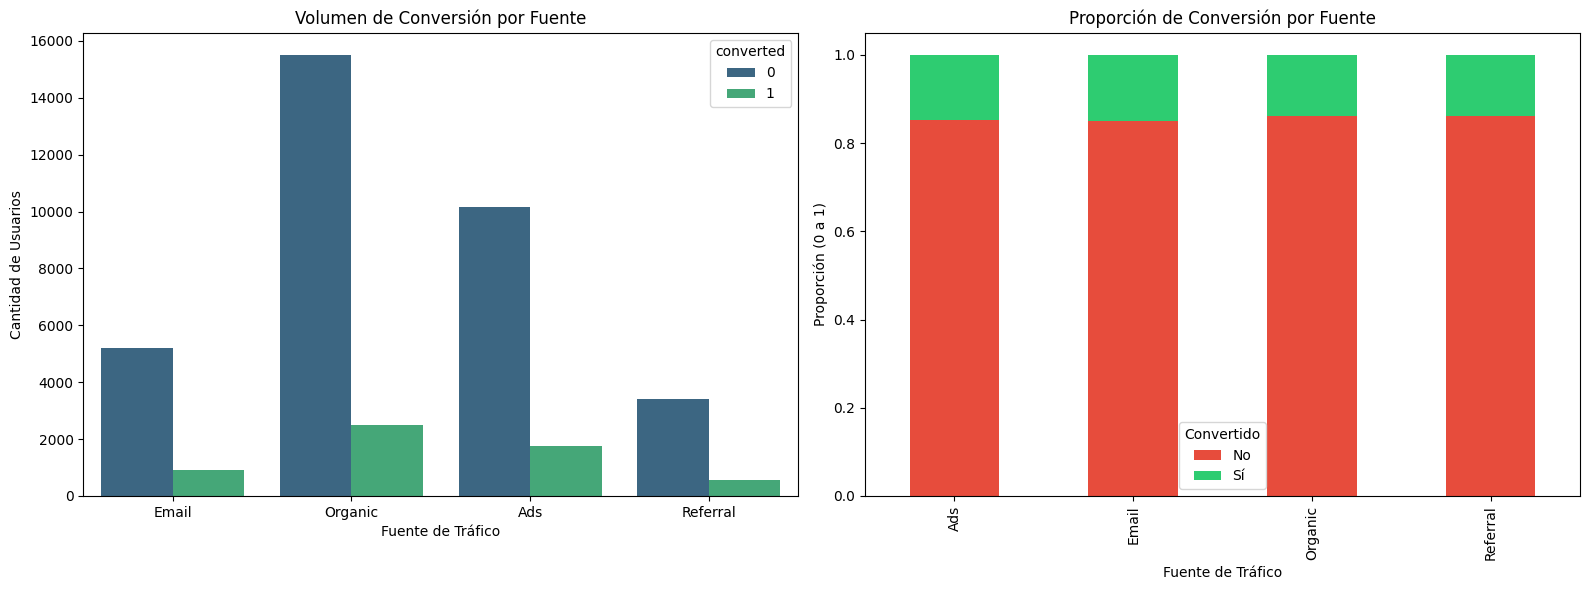

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# A. Cantidad absoluta
sns.countplot(data=df, x='traffic_source', hue='converted', ax=ax[0], palette='viridis')
ax[0].set_title('Volumen de Conversión por Fuente')
ax[0].set_xlabel('Fuente de Tráfico')
ax[0].set_ylabel('Cantidad de Usuarios')

# B. Proporción
proporcion_trafico = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')
proporcion_trafico.plot(kind='bar', stacked=True, ax=ax[1], color=['#e74c3c', '#2ecc71'])
ax[1].set_title('Proporción de Conversión por Fuente')
ax[1].set_xlabel('Fuente de Tráfico')
ax[1].set_ylabel('Proporción (0 a 1)')
ax[1].legend(title='Convertido', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()






✍️ **Comentario**: En la gráfica se visualiza lo que se confirmó con la prueba Chi-cuadrado: las barras de "Email" y "Ads" tienen la sección de éxito ligeramente más alta que las demás.


✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

### Relación entre el tipo de usuario y la conversión

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

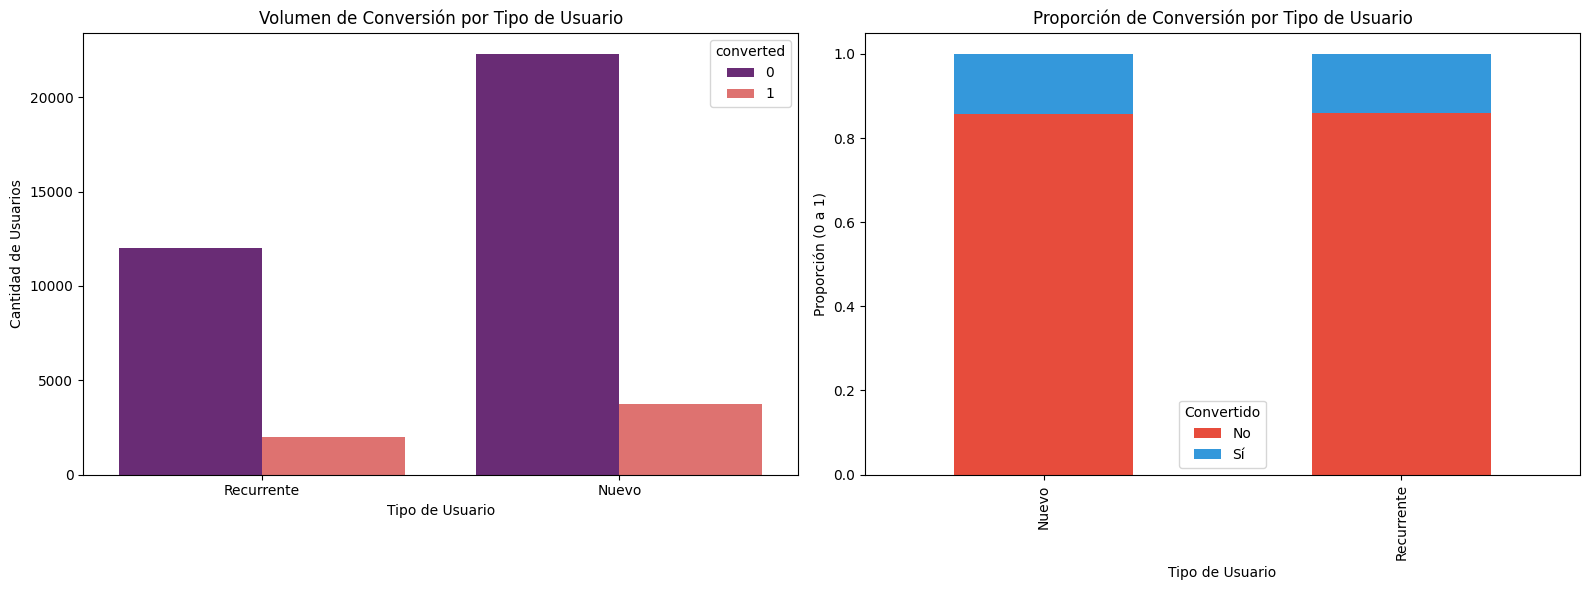

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# A. Cantidad absoluta
sns.countplot(data=df, x='user_type', hue='converted', ax=ax[0], palette='magma')
ax[0].set_title('Volumen de Conversión por Tipo de Usuario')
ax[0].set_xlabel('Tipo de Usuario')
ax[0].set_ylabel('Cantidad de Usuarios')

# B. Proporción
proporcion_usuario = pd.crosstab(df['user_type'], df['converted'], normalize='index')
proporcion_usuario.plot(kind='bar', stacked=True, ax=ax[1], color=['#e74c3c', '#3498db'])
ax[1].set_title('Proporción de Conversión por Tipo de Usuario')
ax[1].set_xlabel('Tipo de Usuario')
ax[1].set_ylabel('Proporción (0 a 1)')
ax[1].legend(title='Convertido', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()


✍️ **Comentario**:

1. En la gráfica de la **izquierda**: Se nota que hay muchísimos más usuarios **Nuevos** en total. y la tasa de conversión es ligeramente más alta en los usuarios nuevos.

2. En la gráfica de la **derecha**, las barras azules tienen exactamente la misma altura en ambas categorías.


## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La Página B obtuvo un promedio de 68.75, mientras que la Página A se quedó en 61.09.
- La prueba T-Student arrojó un valor p extremadamente bajo ($1.06e-20$), confirmando que la diferencia es real.
- **Interpretación:** Los usuarios que compran a través de la Página B gastan un 12.5% más en promedio que los de la Página A.

<br>

**Tasa de conversión:**
- La Página B generó 3,194 conversiones frente a las 2,512 de la Página A.
- El Z-test de proporciones dio un valor p de $0.0000$.
- **Interpretación:** La Página B es significativamente más efectiva para cerrar ventas, aumentando el volumen de clientes captados.

---

#### 📊 **Segmentación por fuente de tráfico**
- Las fuentes de Email (14.99%) y Ads (14.73%) presentan las tasas de conversión más altas.
- **Interpretación:** Existe una asociación significativa entre el origen del tráfico y la compra. El canal de Email Marketing es el más eficiente para atraer usuarios con alta intención de compra.

 ---

#### 📊 **Segmentación por tipo de usuario**
- Los usuarios nuevos (14.35%) y recurrentes (14.09%) tienen tasas de conversión casi idénticas.
- **Interpretación:** El tipo de usuario no influye en la conversión (p-value: 0.4736). La página es igualmente efectiva tanto para fidelizar clientes como para captar prospectos nuevos.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- Se recomienda sustituir la Página A por la Página B de manera permanente, ya que maximiza tanto el volumen de ventas como el ticket promedio.
- Dirigir mayor inversión y esfuerzos de campaña al canal de Email, ya que es el que entrega usuarios de mayor calidad técnica y mayor probabilidad de conversión.
- Dado que la página funciona igual de bien con usuarios nuevos, se recomienda aumentar el gasto en Ads para atraer más tráfico frío, confiando en que la Página B tiene la capacidad de convertirlos sin necesidad de múltiples visitas.